In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

(32, 32, 3)


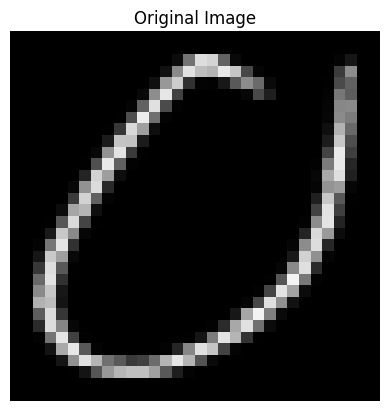

In [6]:
file0 = 'C:/Coding space/Image and Video Processing/project/GROUP10/train/0/4558.png'
img0 = cv2.imread(file0)
print(img0.shape)

plt.imshow(img0, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [65]:
# Training 

check_trining_reached_dict = {
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}

train_pd = pd.read_csv('C:/Coding space/Image and Video Processing/project/GROUP10/train.csv')
trainsize = 1700

labels_list = []
images_list = []

knn = KNeighborsClassifier(n_neighbors=3)

# We randomly select "trainsize" number of images from the train csv and train model
for i in range(trainsize):
    j = random.randint(0, len(train_pd)-1)

    label = train_pd.iloc[j]['Category']

    if check_trining_reached_dict[label] < 40:
        file = 'C:/Coding space/Image and Video Processing/project/GROUP10/train/{}/{}.png'.format(
            label, train_pd.iloc[j]['Id'])
        
        img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

        labels_list.append(label)
        images_list.append(img)
        
        # print('{}: {}'.format(label, file))
        # check_trining_reached_dict[label] += 1
        
        # print("\n")

# print(check_trining_reached_dict)
print('Total number of images selected for training: {}'.format(len(labels_list)))

X = np.array(images_list)
y = np.array(labels_list)

X = X.reshape(X.shape[0], -1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

knn.fit(X_train, y_train)

# test here with 10 random images from the test set
predictions = knn.predict(X_val)
accuracy = accuracy_score(y_val, predictions)

print(f"Internal Validation Accuracy: {accuracy * 100:.2f}%")

# --- TEST WITH 10 RANDOM SAMPLES FROM THE VAL SET ---
print("\n--- Quick Sample Check ---")
for i in range(10):
    idx = random.randint(0, len(X_val) - 1)
    pred = knn.predict(X_val[idx].reshape(1, -1))[0]
    actual = y_val[idx]
    
    status = "✅" if pred == actual else "❌"
    print(f"Sample {i+1}: Actual={actual}, Predicted={pred} {status}")

Total number of images selected for training: 1700
Internal Validation Accuracy: 92.35%

--- Quick Sample Check ---
Sample 1: Actual=8, Predicted=8 ✅
Sample 2: Actual=6, Predicted=7 ❌
Sample 3: Actual=2, Predicted=2 ✅
Sample 4: Actual=4, Predicted=4 ✅
Sample 5: Actual=2, Predicted=2 ✅
Sample 6: Actual=2, Predicted=2 ✅
Sample 7: Actual=1, Predicted=1 ✅
Sample 8: Actual=3, Predicted=3 ✅
Sample 9: Actual=0, Predicted=0 ✅
Sample 10: Actual=2, Predicted=2 ✅


In [ ]:
# Testing TODO: VERY MUCH INCOMPLETE, LOOK AT FURTHUR ABOVE FOR DETAILS AND UNDERSTANDING. Basically ignore this block

# test_pd = pd.read_csv('C:/Coding space/Image and Video Processing/project/GROUP10/test.csv')
test_pd = pd.read_csv('C:/Coding space/Image and Video Processing/project/GROUP10/train.csv')
testsize = 100

test_ids = []
test_labels = []


# for i in range(testsize):

#     j = random.randint(0, len(test_pd)-1)

#     label = test_pd.iloc[j]

#     file = 'C:/Coding space/Image and Video Processing/project/GROUP10/test/{}/{}.png'.format(
#         label, test_pd.iloc[j]['Id'])
    
#     img = cv2.imread(file)
    
#     print('{}: {}'.format(label, file))


ValueError: Index data must be 1-dimensional